In [1]:
#import libraries

In [70]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [2]:
#load dataset 

In [3]:
df = pd.read_csv("employee.csv")
df.head()

,Company,Age,Salary,Place,Country,Gender
0,TCS,20.0,NaN,Chennai,India,0
1,Infosys,30.0,NaN,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0


In [4]:
df.describe()

,Age,Salary,Gender
count,130.000000,124.000000,148.000000
mean,30.484615,5312.467742,0.222973
std,11.096640,2573.764683,0.417654
min,0.000000,1089.000000,0.000000
25%,22.000000,3030.000000,0.000000
50%,32.500000,5000.000000,0.000000
75%,37.750000,8000.000000,0.000000
max,54.000000,9876.000000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Company  140 non-null    object 
 1   Age      130 non-null    float64
 2   Salary   124 non-null    float64
 3   Place    134 non-null    object 
 4   Country  148 non-null    object 
 5   Gender   148 non-null    int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 7.1+ KB


In [6]:
df.isnull().sum()

Company     8
Age        18
Salary     24
Place      14
Country     0
Gender      0
dtype: int64

In [7]:
df.shape

(148, 6)

In [8]:
#Find Unique Values and Their Length

In [9]:
for column in df.columns:
    print("\nColumn:", column)
    print("Unique Values:", df[column].unique())
    print("Number of Unique Values:", df[column].nunique())
    print("Length:", len(df[column].unique()))


Column: Company
Unique Values: ['TCS' 'Infosys' 'CTS' nan 'Tata Consultancy Services' 'Congnizant'
 'Infosys Pvt Lmt']
Number of Unique Values: 6
Length: 7

Column: Age
Unique Values: [20. 30. 35. 40. 23. nan 34. 45. 18. 22. 32. 37. 50. 21. 46. 36. 26. 41.
 24. 25. 43. 19. 38. 51. 31. 44. 33. 17.  0. 54.]
Number of Unique Values: 29
Length: 30

Column: Salary
Unique Values: [  nan 2300. 3000. 4000. 5000. 6000. 7000. 8000. 9000. 1089. 1234. 3030.
 3045. 3184. 4824. 5835. 7084. 8943. 8345. 9284. 9876. 2034. 7654. 2934.
 4034. 5034. 8202. 9024. 4345. 6544. 6543. 3234. 4324. 5435. 5555. 8787.
 3454. 5654. 5009. 5098. 3033.]
Number of Unique Values: 40
Length: 41

Column: Place
Unique Values: ['Chennai' 'Mumbai' 'Calcutta' 'Delhi' 'Podicherry' 'Cochin' nan 'Noida'
 'Hyderabad' 'Bhopal' 'Nagpur' 'Pune']
Number of Unique Values: 11
Length: 12

Column: Country
Unique Values: ['India']
Number of Unique Values: 1
Length: 1

Column: Gender
Unique Values: [0 1]
Number of Unique Values: 2
Length: 

In [10]:
#Rename the Columns

In [11]:
df.rename(columns={
    "Company": "COMPANY",
    "Age": "AGE",
    "Salary": "SALARY",
    "Place": "PLACE",
    "Country": "COUNTRY",
    "Gender": "GENDER"
},inplace=True)

In [12]:
print(df.columns)

Index(['COMPANY', 'AGE', 'SALARY', 'PLACE', 'COUNTRY', 'GENDER'], dtype='object')


In [13]:
#missing values

In [14]:
df.isnull().sum()

COMPANY     8
AGE        18
SALARY     24
PLACE      14
COUNTRY     0
GENDER      0
dtype: int64

In [15]:
#Inappropriate Values

In [16]:
df["AGE"].unique()

array([20., 30., 35., 40., 23., nan, 34., 45., 18., 22., 32., 37., 50.,
       21., 46., 36., 26., 41., 24., 25., 43., 19., 38., 51., 31., 44.,
       33., 17.,  0., 54.])

In [17]:
#Replace Age = 0 with NaN

In [18]:
df["AGE"]=df["AGE"].replace(0,np.nan)

In [19]:
print(df["AGE"].unique())

[20. 30. 35. 40. 23. nan 34. 45. 18. 22. 32. 37. 50. 21. 46. 36. 26. 41.
 24. 25. 43. 19. 38. 51. 31. 44. 33. 17. 54.]


In [20]:
#Handle Inconsistent Company Names

In [21]:
df["COMPANY"] = df["COMPANY"].replace({
    "Tata Consultancy Services": "TCS",
    "Infosys Pvt Lmt": "Infosys",
    "Congnizant": "CTS"
})

In [22]:
print(df.COMPANY)

0          TCS
1      Infosys
2          TCS
3      Infosys
4          TCS
        ...   
143        TCS
144    Infosys
145    Infosys
146        TCS
147    Infosys
Name: COMPANY, Length: 148, dtype: object


In [23]:
#Remove Duplicate Rows

In [24]:
df.duplicated().sum()

np.int64(4)

In [25]:
print(df.duplicated().sum())

4


In [26]:
df.drop_duplicates(inplace=True)

In [27]:
print(df.duplicated().sum())

0


In [28]:
#missing values

In [29]:
df.isnull().sum()

COMPANY     8
AGE        23
SALARY     23
PLACE      14
COUNTRY     0
GENDER      0
dtype: int64

In [30]:
#company

In [31]:
df["COMPANY"]=df["COMPANY"].fillna(df["COMPANY"].mode()[0])

In [32]:
df["COMPANY"].isnull().sum()

np.int64(0)

In [33]:
#age

In [34]:
df["AGE"]=df["AGE"].fillna(df["AGE"].mean())

In [35]:
#salary

In [36]:
df["SALARY"] = df["SALARY"].fillna(df["SALARY"].median())

In [37]:
#place

In [38]:
df["PLACE"] = df["PLACE"].fillna(df["PLACE"].mode()[0])

In [39]:
print(df.isnull().sum())

COMPANY    0
AGE        0
SALARY     0
PLACE      0
COUNTRY    0
GENDER     0
dtype: int64


In [40]:
#outliers in age

In [41]:
q1,q2,q3= np.percentile(df["AGE"],[25,50,75])

In [42]:
print(q1,q2,q3)

23.75 32.04132231404959 36.0


In [43]:
IQR = q3-q1
print(IQR)

12.25


In [44]:
upper_limit = q1 - 1.5*IQR

In [45]:
lower_limit = q3 + 1.5*IQR

In [46]:
print(upper_limit)
print(lower_limit)

5.375
54.375


In [49]:
outlier = []
for i in df["AGE"]:
    if i <lower_limit or i>upper_limit:
        outlier.append(i)
        
print(outlier)

[20.0, 30.0, 35.0, 40.0, 23.0, 32.04132231404959, 32.04132231404959, 23.0, 34.0, 45.0, 23.0, 34.0, 45.0, 18.0, 40.0, 23.0, 23.0, 34.0, 22.0, 32.0, 37.0, 50.0, 21.0, 32.04132231404959, 32.04132231404959, 23.0, 34.0, 45.0, 23.0, 35.0, 46.0, 20.0, 45.0, 36.0, 26.0, 35.0, 32.0, 35.0, 34.0, 41.0, 24.0, 32.04132231404959, 32.04132231404959, 25.0, 35.0, 46.0, 24.0, 32.0, 43.0, 19.0, 41.0, 24.0, 21.0, 35.0, 21.0, 32.0, 38.0, 51.0, 23.0, 32.04132231404959, 32.04132231404959, 25.0, 36.0, 41.0, 25.0, 31.0, 41.0, 21.0, 43.0, 32.0, 21.0, 34.0, 24.0, 34.0, 37.0, 44.0, 32.0, 32.04132231404959, 32.04132231404959, 26.0, 32.0, 43.0, 22.0, 33.0, 17.0, 41.0, 21.0, 32.04132231404959, 36.0, 21.0, 34.0, 32.04132231404959, 54.0, 22.0, 32.04132231404959, 32.04132231404959, 22.0, 33.0, 44.0, 22.0, 32.04132231404959, 44.0, 22.0, 44.0, 33.0, 22.0, 32.04132231404959, 33.0, 33.0, 33.0, 32.04132231404959, 22.0, 32.04132231404959, 32.04132231404959, 22.0, 33.0, 44.0, 22.0, 33.0, 44.0, 32.04132231404959, 44.0, 32.0413

In [51]:
#outlier in salary

In [52]:
q1,q2,q3= np.percentile(df["SALARY"],[25,50,75])

In [53]:
print(q1,q2,q3)

3045.0 5000.0 7084.0


In [54]:
IQR = q3 - q1
print(IQR)

4039.0


In [55]:
upper_limit = q1 - 1.5*IQR
lower_limit = q3 + 1.5*IQR
print(upper_limit)
print(lower_limit)

-3013.5
13142.5


In [56]:
outlier = []
for i in df["SALARY"]:
    if i <lower_limit or i>upper_limit:
        outlier.append(i)
        
print(outlier)

[5000.0, 5000.0, 2300.0, 3000.0, 4000.0, 5000.0, 6000.0, 7000.0, 8000.0, 9000.0, 5000.0, 1089.0, 5000.0, 1234.0, 3000.0, 3000.0, 3030.0, 5000.0, 5000.0, 5000.0, 3045.0, 3184.0, 4824.0, 5835.0, 7084.0, 8943.0, 8345.0, 9284.0, 9876.0, 2034.0, 7654.0, 2934.0, 4034.0, 5034.0, 8202.0, 9024.0, 5000.0, 5000.0, 2300.0, 3000.0, 4345.0, 5000.0, 6000.0, 7000.0, 8000.0, 9000.0, 5000.0, 1089.0, 5000.0, 1234.0, 3000.0, 3000.0, 3030.0, 5000.0, 6544.0, 7654.0, 3045.0, 3184.0, 4824.0, 5835.0, 7084.0, 8943.0, 8345.0, 9284.0, 6543.0, 2034.0, 5000.0, 2934.0, 4034.0, 5034.0, 8202.0, 9024.0, 5000.0, 5000.0, 2300.0, 3000.0, 4000.0, 5000.0, 6000.0, 7000.0, 8000.0, 9000.0, 5000.0, 1089.0, 1234.0, 3000.0, 3000.0, 3030.0, 5000.0, 5000.0, 5000.0, 3045.0, 3184.0, 4824.0, 5835.0, 7084.0, 8943.0, 8345.0, 9284.0, 5000.0, 2034.0, 5000.0, 2934.0, 4034.0, 5034.0, 8202.0, 9024.0, 5000.0, 5000.0, 2300.0, 3234.0, 4324.0, 5435.0, 5555.0, 8787.0, 8787.0, 9876.0, 5000.0, 1089.0, 5000.0, 1234.0, 3234.0, 3454.0, 8787.0, 5654.0,

In [57]:
#Filter the data with age > 40 and salary < 5000.

In [59]:
filtered_df = df[
    (df["AGE"] > 40) &
    (df["SALARY"] < 5000)
]

print(filtered_df)

     COMPANY   AGE  SALARY      PLACE COUNTRY  GENDER
21   Infosys  50.0  3184.0      Delhi   India       0
32   Infosys  45.0  4034.0   Calcutta   India       0
39   Infosys  41.0  3000.0     Mumbai   India       0
50   Infosys  41.0  3000.0    Chennai   India       0
57   Infosys  51.0  3184.0  Hyderabad   India       0
68   Infosys  43.0  4034.0     Mumbai   India       0
75   Infosys  44.0  3000.0     Cochin   India       0
86   Infosys  41.0  3000.0      Delhi   India       0
93   Infosys  54.0  3184.0     Mumbai   India       0
104  Infosys  44.0  4034.0      Delhi   India       0
122  Infosys  44.0  3234.0     Mumbai   India       0
129  Infosys  50.0  3184.0   Calcutta   India       0
138      CTS  44.0  3033.0     Cochin   India       0
140  Infosys  44.0  4034.0  Hyderabad   India       0
145  Infosys  44.0  4034.0      Delhi   India       1


In [60]:
#plot

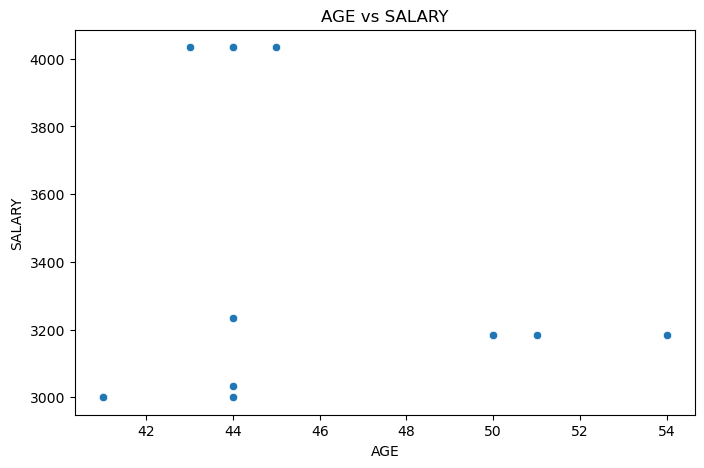

In [61]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=filtered_df,
    x="AGE",
    y="SALARY"
)

plt.title("AGE vs SALARY")
plt.xlabel("AGE")
plt.ylabel("SALARY")

plt.show()

In [63]:
#Count the number of people from each place

In [65]:
place_count = df["PLACE"].value_counts()
print(place_count)



PLACE
Mumbai        48
Calcutta      32
Chennai       14
Delhi         14
Cochin        13
Noida          8
Hyderabad      8
Podicherry     3
Pune           2
Bhopal         1
Nagpur         1
Name: count, dtype: int64


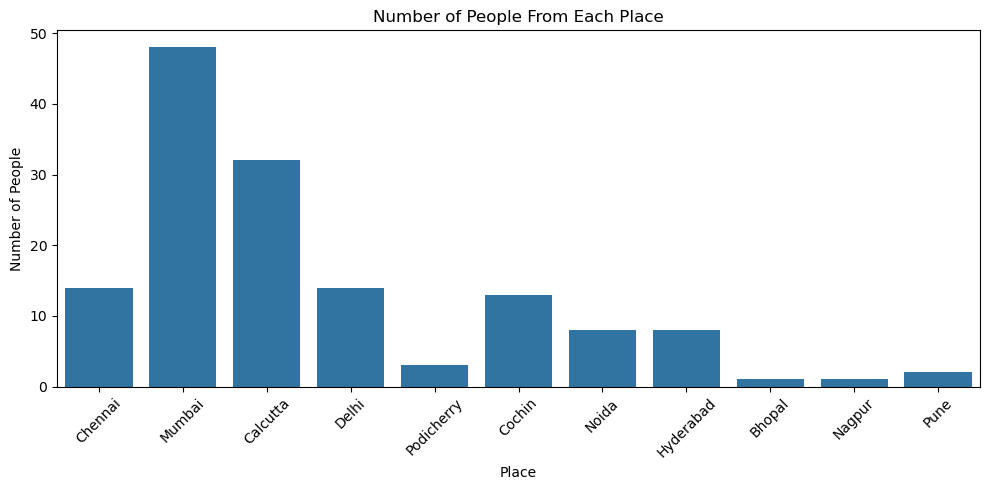

In [67]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="PLACE"
)

plt.title("Number of People From Each Place")
plt.xlabel("Place")
plt.ylabel("Number of People")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [68]:
#label encoding

In [71]:
label_encoder = LabelEncoder()

df_label = df.copy()

df_label["COMPANY"] = label_encoder.fit_transform(
    df_label["COMPANY"]
)

df_label["PLACE"] = label_encoder.fit_transform(
    df_label["PLACE"]
)

df_label["COUNTRY"] = label_encoder.fit_transform(
    df_label["COUNTRY"]
)

df_label.head()

,COMPANY,AGE,SALARY,PLACE,COUNTRY,GENDER
0,2,20.0,5000.0,2,0,0
1,1,30.0,5000.0,6,0,0
2,2,35.0,2300.0,1,0,0
3,1,40.0,3000.0,4,0,0
4,2,23.0,4000.0,6,0,0


In [72]:
#onehot encoding

In [73]:
df_encoded = pd.get_dummies(
    df,
    columns=["COMPANY", "PLACE", "COUNTRY"],
    drop_first=True,
    dtype=int
)

df_encoded.head()

,AGE,SALARY,GENDER,COMPANY_Infosys,COMPANY_TCS,PLACE_Calcutta,PLACE_Chennai,PLACE_Cochin,PLACE_Delhi,PLACE_Hyderabad,PLACE_Mumbai,PLACE_Nagpur,PLACE_Noida,PLACE_Podicherry,PLACE_Pune
0,20.0,5000.0,0,0,1,0,1,0,0,0,0,0,0,0,0
1,30.0,5000.0,0,1,0,0,0,0,0,0,1,0,0,0,0
2,35.0,2300.0,0,0,1,1,0,0,0,0,0,0,0,0,0
3,40.0,3000.0,0,1,0,0,0,0,1,0,0,0,0,0,0
4,23.0,4000.0,0,0,1,0,0,0,0,0,1,0,0,0,0


In [75]:
#StandardScaler

In [74]:
standard_scaler = StandardScaler()

df_standardized = pd.DataFrame(
    standard_scaler.fit_transform(df_encoded),
    columns=df_encoded.columns
)

df_standardized.head()

,AGE,SALARY,GENDER,COMPANY_Infosys,COMPANY_TCS,PLACE_Calcutta,PLACE_Chennai,PLACE_Cochin,PLACE_Delhi,PLACE_Hyderabad,PLACE_Mumbai,PLACE_Nagpur,PLACE_Noida,PLACE_Podicherry,PLACE_Pune
0,-1.467376,-0.100827,-0.534522,-0.67420,1.150035,-0.534522,3.047247,-0.315018,-0.328165,-0.242536,-0.707107,-0.083624,-0.242536,-0.145865,-0.118678
1,-0.248759,-0.100827,-0.534522,1.48324,-0.869539,-0.534522,-0.328165,-0.315018,-0.328165,-0.242536,1.414214,-0.083624,-0.242536,-0.145865,-0.118678
2,0.360549,-1.243735,-0.534522,-0.67420,1.150035,1.870829,-0.328165,-0.315018,-0.328165,-0.242536,-0.707107,-0.083624,-0.242536,-0.145865,-0.118678
3,0.969858,-0.947426,-0.534522,1.48324,-0.869539,-0.534522,-0.328165,-0.315018,3.047247,-0.242536,-0.707107,-0.083624,-0.242536,-0.145865,-0.118678
4,-1.101791,-0.524127,-0.534522,-0.67420,1.150035,-0.534522,-0.328165,-0.315018,-0.328165,-0.242536,1.414214,-0.083624,-0.242536,-0.145865,-0.118678


In [76]:
#MinMaxScaler

In [77]:
minmax_scaler = MinMaxScaler()

df_minmax = pd.DataFrame(
    minmax_scaler.fit_transform(df_encoded),
    columns=df_encoded.columns
)

df_minmax.head()

,AGE,SALARY,GENDER,COMPANY_Infosys,COMPANY_TCS,PLACE_Calcutta,PLACE_Chennai,PLACE_Cochin,PLACE_Delhi,PLACE_Hyderabad,PLACE_Mumbai,PLACE_Nagpur,PLACE_Noida,PLACE_Podicherry,PLACE_Pune
0,0.081081,0.445089,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.351351,0.445089,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.486486,0.137817,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.621622,0.217480,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.162162,0.331285,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
